#### 6) Required System 1: Baseline RAG Pipeline
Implement a baseline RAG pipeline as follows:
1. Mine text from the document content (e.g. using any pdf processing library)

Deciding on a pdf processing library I checked a guys tips here: \
https://onlyoneaman.medium.com/i-tested-7-python-pdf-extractors-so-you-dont-have-to-2025-edition-c88013922257

- marker-pdf (11.3s): Perfect structure preservation, ideal for high-quality conversions, long time though
- pymupdf4llm (0.12s): Excellent markdown output, great balance of speed and quality
- unstructured (1.29s): Clean semantic chunks, perfect for RAG workflows
- textract (0.21s): Fast with OCR capabilities, minor formatting variations
- pypdfium2 (0.003s): Blazing speed, clean basic text, no structure
- pypdf (0.024s): Reliable extraction, occasional spacing artifacts
- pdfplumber (0.10s): Good for tables, text extraction needs configuration

For RAG systems he recommended `unstructured`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from typing import List, Dict, Any
from unstructured.partition.auto import partition

In [2]:
print(os.getcwd())
path = "../data/train/pdfs_train/0b85477387a9d0cc33fca0f4becaa0e5.pdf"
os.path.exists(path)

c:\Users\kiran\Documents\_UIS\sem8\DAT560_GenerativAI_10\DAT560project\src\notebooks


True

In [3]:
# pip install "unstructured[all-docs]"
blocks = partition(filename=path)

In [4]:
for block in blocks:
    print(f"{block.category}: {block.text}")

Header: NMR&D News
Title: Volume IV, Issue 12
Title: In this issue…
NarrativeText: 2 CO‟s Messages 3 Building Afghan Medical Capacity 4 USNS Mercy Pacific Partnership 5 DoD Bone Marrow Donor Program 6 ID Joint Planning Group 7 Capacity Building in Liberia 8 Kazakh Scientists Train at NMRC 9 Patient Condition Occurrence Tool 10 Combat Casualty Research Team 11 Accelerating Technology Transfer 12 NMRC Hosts Dining Out 13 Villasante Speaks at Notre Dame 14 Keane-Myers Speaks at Hopkins 14 Cub Scouts Learn Flag Etiquette 15 NMRC High School Outreach NMRC Officers Teach Science 15 2012 Combined Federal Campaign 16 16 Ombudsman‟s Note
NarrativeText: NMR&D News is an authorized publica- tion of the Naval Medical Research Center, 503 Robert Grant Avenue, Silver Spring, MD 20910. NMR&D News is published monthly by the NMRC Public Affairs Office, 301-319-9378 or svc.pao.nmrc@med.navy.mil .
NarrativeText: Commanding Officer Capt. John W. Sanders
Title: Executive Officer Capt. Elizabeth Montcalm-S

In [5]:
# 1. First chunking strategy test
def chunking_equal_size():
    current_chunk, chunks = [], []
    text_len, max_chars, blocks_count = 0, 1000, len(blocks)
    for i, block in enumerate(blocks):
        text = block.text.strip()
        text_len += len(text)
        current_chunk.append(text)
        
        if text_len > max_chars or i == blocks_count - 1:
            chunks.append(" ". join(current_chunk))
            current_chunk = []
            text_len = 0
    return chunks

##### Just checking the length distribution to see if its alright

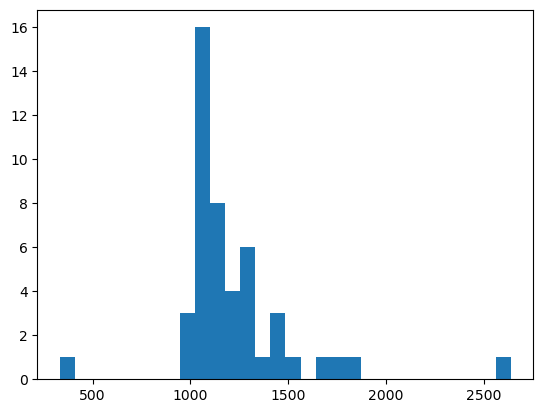

In [36]:
chunks = chunking_equal_size()

def plot_chunk_size_distribution(chunks):
    dist = {}
    for chunk in chunks:
        length = len(chunk)
        dist[length] = dist.get(length, 0) + 1
    
    lengths = [len(chunk) for chunk in chunks]
    plt.hist(lengths, bins=30)

plot_chunk_size_distribution(chunks)

- uh oh, large variance in output, This may not be a good approach since the embedding could be 'stretched' or 'squished' containing too much or too little. So we will fall back on this and instead actually do fixed size, and then the 3 other methods will improve upon this. Since this output is very similar to semantic output probably.

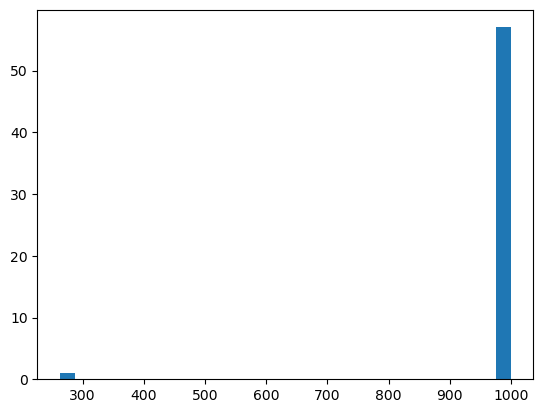

In [ ]:
def fixed_size(blocks):
    text = " ".join(block.text for block in blocks if hasattr(block, "text"))
    chunks = [text[i:i+1000] for i in range(0, len(text), 1000)]
    return chunks

fixed_size_blocks = fixed_size(blocks)
plot_chunk_size_distribution(fixed_size_blocks)

#### 6.2) Required System 1: Baseline RAG Pipeline 
2. Encode document content (use text at minimum)  

In [3]:
from transformers import CLIPModel, CLIPProcessor
from PIL import Image

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [ ]:

def embed_img(path):
    image = Image.open(path)
    img_inputs = processor(images=image, return_tensors="pt")
    img_emb = model.get_image_features(**img_inputs)
    return img_emb

def embed_text(chunk):
    txt_inputs = processor(text=[chunk], return_tensors="pt", padding=True, truncation=True)
    txt_emb = model.get_text_features(**txt_inputs)    # [1, 512]
    return txt_emb

embedding = embed_text("Hi my name is Joe mama")

In [ ]:
embedding.shape


torch.Size([1, 512])

#### Focusing on just finishing different chunking strategies

In [ ]:
class Chunking:
    def __init__(self, blocks: List):
        self.blocks = blocks

    def _make_chunk(texts: List[str]) -> Dict[str, Any]:
        chunk_text = " ".join(texts)
        return {"text": " ".chunk_text, "char_len": len(chunk_text)}

    def fixed_size(self, max_chars: int = 1000):
        text = " ".join(block.text for block in self.blocks)
        chunks = []
        for i in range(0, len(text), max_chars):
            chunks.append(self._make_chunk(text[i : i + max_chars]))
        return chunks

    def sliding_window(self, window_charts: int = 1000, overlap_chars: int = 200):
        pass
    
chunking = Chunking(blocks)
chunks_fixed = chunking.fixed_size()

plot_chunk_size_distribution(chunks_fixed)